In [16]:
import pandas as pd
import numpy as np

# Load Iris dataset (built-in, no download needed)
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [17]:
# First look (Always do this)
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum()) # check missing values


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             

In [18]:
# Selecting data
df['sepal length (cm)']                 # Series (1 column)
df[['sepal length (cm)', 'species']]    # DataFrame (multiple coulmns)
df.iloc[0]                              # first row by position
df.loc[df['species'] == 'setosa']       # filter rows

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [19]:
# Creating columns
df['sepal_area'] = df['sepal length (cm)'] * df['sepal width (cm)']

In [20]:
# Groupby (powerful for EDA)
df.groupby('species') ['sepal length (cm)'].mean()
df.groupby('species').agg({
    'sepal length (cm)': ['mean', 'std'],
    'petal length (cm)': ['mean', 'std']
})

sepal length (cm)           petal length (cm)          
                        mean       std              mean       std
species                                                           
setosa                 5.006  0.352490             1.462  0.173664
versicolor             5.936  0.516171             4.260  0.469911
virginica              6.588  0.635880             5.552  0.551895

In [21]:
# Sorting
df.sort_values('sepal length (cm)', ascending=False).head()

# Value counts
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [22]:
# --- Download Titanic dataset ---
# Go to kaggle.com/c/titanic/data, download train.csv
# OR use seaborn built-in:
import seaborn as sns
titanic = sns.load_dataset('titanic')
print(titanic.head())
print(titanic.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64

In [23]:
# Missing values (real-world #1 task)
print(titanic.isnull().sum())
print(titanic.isnull().sum() / len(titanic) * 100) # % missing values

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [24]:
# Strategy 1: Drop rows with too many missing values
titanic_clean = titanic.dropna(subset=['age', 'fare'])

# Strategy 2: Fill missing values with median/mode
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

In [25]:
# Data types
titanic['sex'] = titanic['sex'].astype('category')
titanic['embarked'] = titanic['embarked'].astype('category')

# One-hot encoding (needed for ML models)
encoded = pd.get_dummies(titanic, columns=['sex', 'embarked'], drop_first=True)
print(encoded.head())

   survived  pclass   age  sibsp  parch     fare  class    who  adult_male  \
0         0       3  22.0      1      0   7.2500  Third    man        True   
1         1       1  38.0      1      0  71.2833  First  woman       False   
2         1       3  26.0      0      0   7.9250  Third  woman       False   
3         1       1  35.0      1      0  53.1000  First  woman       False   
4         0       3  35.0      0      0   8.0500  Third    man        True   

  deck  embark_town alive  alone  sex_male  embarked_Q  embarked_S  
0  NaN  Southampton    no  False      True       False        True  
1    C    Cherbourg   yes  False     False       False       False  
2  NaN  Southampton   yes   True     False       False        True  
3    C  Southampton   yes  False     False       False        True  
4  NaN  Southampton    no   True      True       False        True  


In [26]:
# Merging (like SQL join)
# create a sample swecond table
survival_rates = titanic.groupby('class')['survived'].mean().reset_index()
survival_rates.columns = ['class', 'class_survival_rate']
merged = titanic.merge(survival_rates, on='class', how='left')


In [28]:
# Apply custom functions
titanic['fare_category'] = titanic['fare'].apply(
    lambda x: 'cheap' if x < 20 else ('medium' if x < 50 else 'expensive')
)

# Pivot tables
pivot = titanic.pivot_table(
    values='survived',
    index='class',
    columns='sex',
    aggfunc='mean'
)
print(pivot)

sex       female      male
class                     
First   0.968085  0.368852
Second  0.921053  0.157407
Third   0.500000  0.135447


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style once
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)



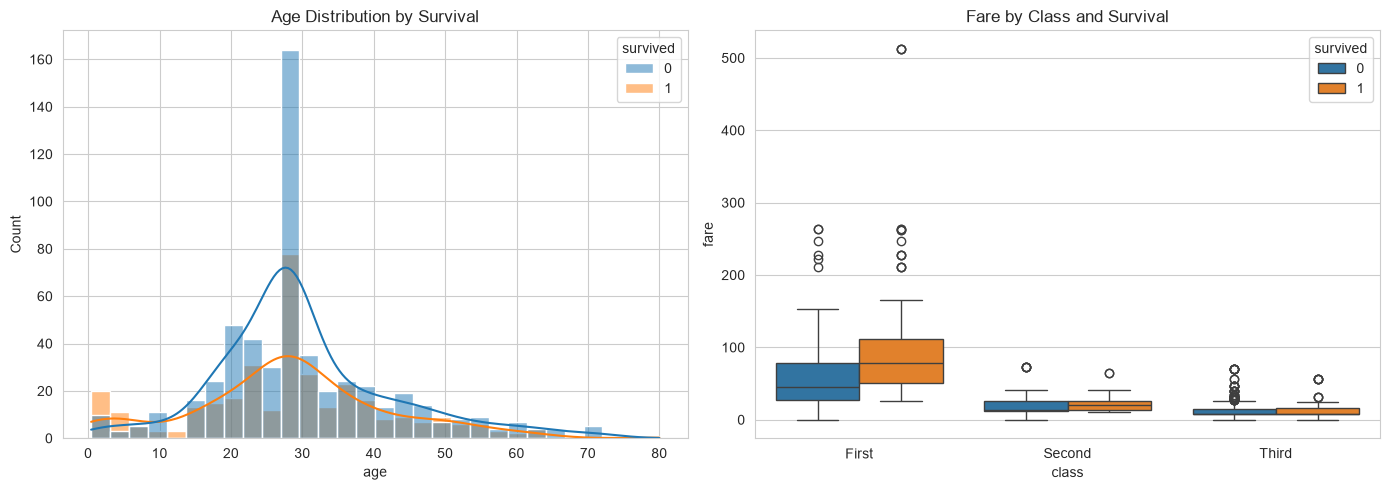

In [32]:
# 1. Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=titanic, x='age', hue='survived', kde=True, ax=axes[0])
axes[0].set_title('Age Distribution by Survival')

sns.boxplot(data=titanic, x='class', y='fare', hue='survived', ax=axes[1])
axes[1].set_title('Fare by Class and Survival')

plt.tight_layout()
plt.savefig('../data/titanic_eda_1.png', dpi=150)
plt.show()